# Churn Prediction Model Training

This notebook trains a machine learning model to predict customer churn with a target accuracy of >70%.

## Step 1: Import Required Libraries

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import os

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")
print(f"XGBoost version: {xgb.__version__}")
print(f"LightGBM version: {lgb.__version__}")

Libraries imported successfully!
XGBoost version: 3.0.5
LightGBM version: 4.6.0


## Step 2: Load and Prepare Data

In [135]:
# Change to the correct working directory
notebook_path = '/home/abhishekg/Documents/flying-fish'
os.chdir(notebook_path)
print(f"Changed working directory to: {os.getcwd()}")

# Define the data directory
data_dir = Path('data')

# Load all datasets
print("Loading datasets...")
address_df = pd.read_csv(data_dir / 'address.csv')
customer_df = pd.read_csv(data_dir / 'customer.csv')
demographic_df = pd.read_csv(data_dir / 'demographic.csv')
termination_df = pd.read_csv(data_dir / 'termination.csv')
autoinsurance_df = pd.read_csv(data_dir / 'autoinsurance_churn.csv')

print(f"Address dataset: {address_df.shape}")
print(f"Customer dataset: {customer_df.shape}")
print(f"Demographic dataset: {demographic_df.shape}")
print(f"Termination dataset: {termination_df.shape}")
print(f"AutoInsurance dataset: {autoinsurance_df.shape}")

# Use only first 10,000 rows for now
# print(f"\nUsing first {SAMPLE_SIZE} records for training...")

Changed working directory to: /home/abhishekg/Documents/flying-fish
Loading datasets...
Address dataset: (1536673, 7)
Customer dataset: (2280321, 8)
Demographic dataset: (2112579, 9)
Termination dataset: (269259, 2)
AutoInsurance dataset: (1680909, 22)


In [136]:
# Check column names in all datasets
print("Column names in each dataset:")
print("\nAddress columns:", address_df.columns.tolist())
print("\nCustomer columns:", customer_df.columns.tolist())
print("\nDemographic columns:", demographic_df.columns.tolist())
print("\nTermination columns:", termination_df.columns.tolist())
print("\nAutoInsurance columns:", autoinsurance_df.columns.tolist())

Column names in each dataset:

Address columns: ['ADDRESS_ID', 'LATITUDE', 'LONGITUDE', 'STREET_ADDRESS', 'CITY', 'STATE', 'COUNTY']

Customer columns: ['INDIVIDUAL_ID', 'ADDRESS_ID', 'CURR_ANN_AMT', 'DAYS_TENURE', 'CUST_ORIG_DATE', 'AGE_IN_YEARS', 'DATE_OF_BIRTH', 'SOCIAL_SECURITY_NUMBER']

Demographic columns: ['INDIVIDUAL_ID', 'INCOME', 'HAS_CHILDREN', 'LENGTH_OF_RESIDENCE', 'MARITAL_STATUS', 'HOME_MARKET_VALUE', 'HOME_OWNER', 'COLLEGE_DEGREE', 'GOOD_CREDIT']

Termination columns: ['INDIVIDUAL_ID', 'ACCT_SUSPD_DATE']

AutoInsurance columns: ['individual_id', 'address_id', 'curr_ann_amt', 'days_tenure', 'cust_orig_date', 'age_in_years', 'date_of_birth', 'latitude', 'longitude', 'city', 'state', 'county', 'income', 'has_children', 'length_of_residence', 'marital_status', 'home_market_value', 'home_owner', 'college_degree', 'good_credit', 'acct_suspd_date', 'Churn']


## Step 3: Use Merged Dataset

In [137]:
# Use the autoinsurance dataset which already has all data merged
print("Using autoinsurance dataset...")
df = autoinsurance_df.copy()

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Using autoinsurance dataset...
Dataset shape: (1680909, 22)

Column names:
['individual_id', 'address_id', 'curr_ann_amt', 'days_tenure', 'cust_orig_date', 'age_in_years', 'date_of_birth', 'latitude', 'longitude', 'city', 'state', 'county', 'income', 'has_children', 'length_of_residence', 'marital_status', 'home_market_value', 'home_owner', 'college_degree', 'good_credit', 'acct_suspd_date', 'Churn']

First few rows:


,individual_id,address_id,curr_ann_amt,days_tenure,cust_orig_date,age_in_years,date_of_birth,latitude,longitude,city,...,income,has_children,length_of_residence,marital_status,home_market_value,home_owner,college_degree,good_credit,acct_suspd_date,Churn
0,2.213000e+11,5.213000e+11,818.877997,1454.0,2018-12-09,44,1978-06-23,32.578829,-96.305006,Kaufman,...,22500.0,1.0,15.0,Married,50000 - 74999,1.0,1.0,1.0,NaN,0
1,2.213001e+11,5.213001e+11,974.199182,1795.0,2018-01-02,72,1950-05-30,32.732209,-97.000893,Grand Prairie,...,27500.0,0.0,2.0,Single,50000 - 74999,1.0,0.0,0.0,NaN,0
2,2.213007e+11,5.213002e+11,967.375112,4818.0,2009-09-23,55,1967-07-07,32.819777,-96.846938,Dallas,...,42500.0,0.0,10.0,Married,75000 - 99999,1.0,0.0,0.0,NaN,0
3,2.213016e+11,5.213006e+11,992.409561,130.0,2022-07-25,53,1969-05-25,32.684065,-97.162180,Arlington,...,125000.0,1.0,6.0,Married,175000 - 199999,1.0,0.0,1.0,2021-12-22,1
4,2.213016e+11,5.213006e+11,784.633494,5896.0,2006-10-11,50,1972-09-25,32.751398,-97.376745,Fort Worth,...,87500.0,1.0,4.0,Married,225000 - 249999,1.0,1.0,1.0,NaN,0


## Step 4: Data Preprocessing

In [138]:
# Check for target variable
print("Target variable distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].mean():.2%}")

# Check for missing values
print("\n" + "="*80)
print("Missing values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_df)

Target variable distribution:
Churn
0    1487453
1     193456
Name: count, dtype: int64

Churn rate: 11.51%

Missing values:
               Column  Missing_Count  Missing_Percentage
20    acct_suspd_date        1487453           88.490989
7            latitude         253719           15.094154
8           longitude         253719           15.094154
16  home_market_value          92286            5.490244
9                city          12067            0.717885
11             county          12067            0.717885


In [139]:
# Feature engineering and selection
print("Feature Engineering...")

# Drop columns that are identifiers or have too many missing values
cols_to_drop = ['individual_id', 'address_id', 'date_of_birth', 'cust_orig_date', 'acct_suspd_date']

# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove target and identifier columns from feature lists
if 'Churn' in numeric_cols:
    numeric_cols.remove('Churn')
for col in cols_to_drop:
    if col in numeric_cols:
        numeric_cols.remove(col)
    if col in categorical_cols:
        categorical_cols.remove(col)

print(f"\nNumeric columns: {len(numeric_cols)}")
print(numeric_cols)
print(f"\nCategorical columns: {len(categorical_cols)}")
print(categorical_cols)

Feature Engineering...

Numeric columns: 11
['curr_ann_amt', 'days_tenure', 'age_in_years', 'latitude', 'longitude', 'income', 'has_children', 'length_of_residence', 'home_owner', 'college_degree', 'good_credit']

Categorical columns: 5
['city', 'state', 'county', 'marital_status', 'home_market_value']


In [140]:
# Handle missing values
# Drop the acct_suspd_date column since it has too many missing values and is not needed for prediction
print("Handling missing values...")

# Create a working copy
df_clean = df.copy()

# Fill numeric missing values with median
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
        
# Fill categorical missing values with mode or 'Unknown'
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].mode().shape[0] > 0:
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
        else:
            df_clean[col].fillna('Unknown', inplace=True)

df_clean = df_clean.drop(columns=['individual_id', 'address_id', 'date_of_birth', 'cust_orig_date', 'acct_suspd_date'])
print(f"Dropped acct_suspd_date column")

print(f"Missing values after cleaning: {df_clean.isnull().sum().sum()}")
print(f"Data shape after handling missing values: {df_clean.shape}")

Handling missing values...
Dropped acct_suspd_date column
Missing values after cleaning: 0
Data shape after handling missing values: (1680909, 17)


In [141]:
# Encode categorical variables
print("Encoding categorical variables...")

# Use Label Encoding for categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le
    
print(f"Encoded {len(categorical_cols)} categorical columns")
print(f"\nData shape after encoding: {df_clean.shape}")

Encoding categorical variables...
Encoded 5 categorical columns

Data shape after encoding: (1680909, 17)


## Step 5: Split the Data

In [142]:
# Prepare features and target
print("Preparing features and target...")

# Select features (exclude identifier columns and target)
feature_cols = [col for col in df_clean.columns if col not in ['Churn', 'individual_id', 'address_id', 'date_of_birth', 'cust_orig_date', 'acct_suspd_date']]
X = df_clean[feature_cols]
y = df_clean['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")

# Split into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training set churn rate: {y_train.mean():.2%}")
print(f"Test set churn rate: {y_test.mean():.2%}")

Preparing features and target...
Features shape: (1680909, 16)
Target shape: (1680909,)

Target distribution:
Churn
0    1487453
1     193456
Name: count, dtype: int64

Training set size: 1344727
Test set size: 336182
Training set churn rate: 11.51%
Test set churn rate: 11.51%


In [143]:
# Scale features (important for Logistic Regression)
print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")

Scaling features...
Features scaled successfully!


## Step 6: Train Model

## XGBoost Classifier

In [145]:
# Train XGBoost
print("Training XGBoost Classifier...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Calculate metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("\n" + "="*80)
print("XGBOOST RESULTS")
print("="*80)
print(f"Accuracy:  {accuracy_xgb:.4f} ({accuracy_xgb*100:.2f}%)")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall:    {recall_xgb:.4f}")
print(f"F1-Score:  {f1_xgb:.4f}")
print("\n" + "="*80)

# Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['No Churn', 'Churn']))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\nConfusion Matrix:")
print(cm_xgb)

Training XGBoost Classifier...

XGBOOST RESULTS
Accuracy:  0.8844 (88.44%)
Precision: 0.4952
Recall:    0.2144
F1-Score:  0.2993


Detailed Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.97      0.94    297491
       Churn       0.50      0.21      0.30     38691

    accuracy                           0.88    336182
   macro avg       0.70      0.59      0.62    336182
weighted avg       0.86      0.88      0.86    336182


Confusion Matrix:
[[289033   8458]
 [ 30394   8297]]


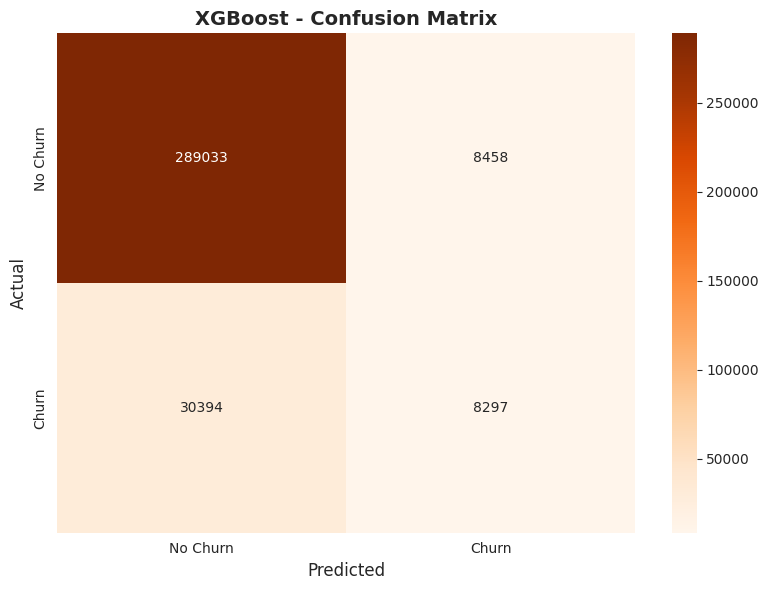

In [146]:
# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('XGBoost - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

In [151]:
import joblib
import pickle

# Save the XGBoost model and related components for future use

print("="*80)
print("SAVING XGBOOST MODEL")
print("="*80)
# 1. Save the trained XGBoost model
model_filename = f'xgboost_churn_model.pkl'
joblib.dump(xgb_model, model_filename)
print(f"✓ Saved XGBoost model to: {model_filename}")

SAVING XGBOOST MODEL
✓ Saved XGBoost model to: xgboost_churn_model.pkl
